## **Superstore Sales Analysis**- Business Intelligence Analysis

**Dataset:** Kaggle Superstore Sales 

**Author:** Lina Maatouk 

**Tools:** Python, Pandas, Matplotlib, Seaborn, Plotly, Sklearn

## **Project Overview**
This project aims to analyze a US retail superstore's transactional data (9,800 orders) found on Kaggle. The goal is to surface actionable insights across sales performance, customer segmentation, product profitability, and regional trends.

### **Exploratory Data Analysis**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [3]:
df = pd.read_csv('train.csv', parse_dates=['Order Date', 'Ship Date'])
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [6]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

In [7]:
df.describe()

,Row ID,Postal Code,Sales
count,9789.000000,9789.000000,9789.000000
mean,4896.705588,55273.322403,230.116193
std,2827.486899,32041.223413,625.302079
min,1.000000,1040.000000,0.444000
25%,2449.000000,23223.000000,17.248000
50%,4896.000000,58103.000000,54.384000
75%,7344.000000,90008.000000,210.392000
max,9800.000000,99301.000000,22638.480000


#### Observations:

##### *Sales* has a **mean of 230.11** but a **median of $54.38**. This would be heavily right-skewed, meaning a small number of large orders pull the average up significantly

In [14]:
df.shape

(9789, 18)

In [15]:
# Fix date parsing (format is DD/MM/YYYY in this dataset)
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  dayfirst=True)

# Cast Postal Code to string (it's an ID, not a number)
df['Postal Code'] = df['Postal Code'].astype(int).astype(str)

# Confirm
print(df[['Order Date', 'Ship Date']].dtypes)
print(f"Date range: {df['Order Date'].min().date()} → {df['Order Date'].max().date()}")

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object
Date range: 2015-01-03 → 2018-12-30


In [16]:
df.duplicated().sum()

np.int64(0)

In [66]:
df['Ship Days']     = (df['Ship Date'] - df['Order Date']).dt.days
df['Order Year']    = df['Order Date'].dt.year
df['Order Month']   = df['Order Date'].dt.month
df['Order Quarter'] = df['Order Date'].dt.to_period('Q').astype(str)
df['YearMonth']     = df['Order Date'].dt.to_period('M').astype(str)

df[['Order Date', 'Ship Date', 'Ship Days', 'Order Year', 'Order Quarter']].head()

,Order Date,Ship Date,Ship Days,Order Year,Order Quarter
0,2017-11-08,2017-11-11,3,2017,2017Q4
1,2017-11-08,2017-11-11,3,2017,2017Q4
2,2017-06-12,2017-06-16,4,2017,2017Q2
3,2016-10-11,2016-10-18,7,2016,2016Q4
4,2016-10-11,2016-10-18,7,2016,2016Q4


##### Key Business Metrics

In [ ]:
print("=" * 40)
print("      KEY BUSINESS METRICS")
print("=" * 40)
print(f"  Total Revenue     : ${df['Sales'].sum():>12,.2f}")
print(f"  Total Orders      : {df['Order ID'].nunique():>12,}")
print(f"  Unique Customers  : {df['Customer ID'].nunique():>12,}")
print(f"  Unique Products   : {df['Product ID'].nunique():>12,}")
print(f"  Avg Order Value   : ${df.groupby('Order ID')['Sales'].sum().mean():>12,.2f}")
print(f"  Avg Shipping Days : {df['Ship Days'].mean():>12.1f}")
print("=" * 40)

      KEY BUSINESS METRICS
  Total Revenue     : $2,252,607.41
  Total Orders      :        4,916
  Unique Customers  :          793
  Unique Products   :        1,860
  Avg Order Value   : $      458.22
  Avg Shipping Days :          4.0


## **Visualizations**

#### Monthly Sales Trend

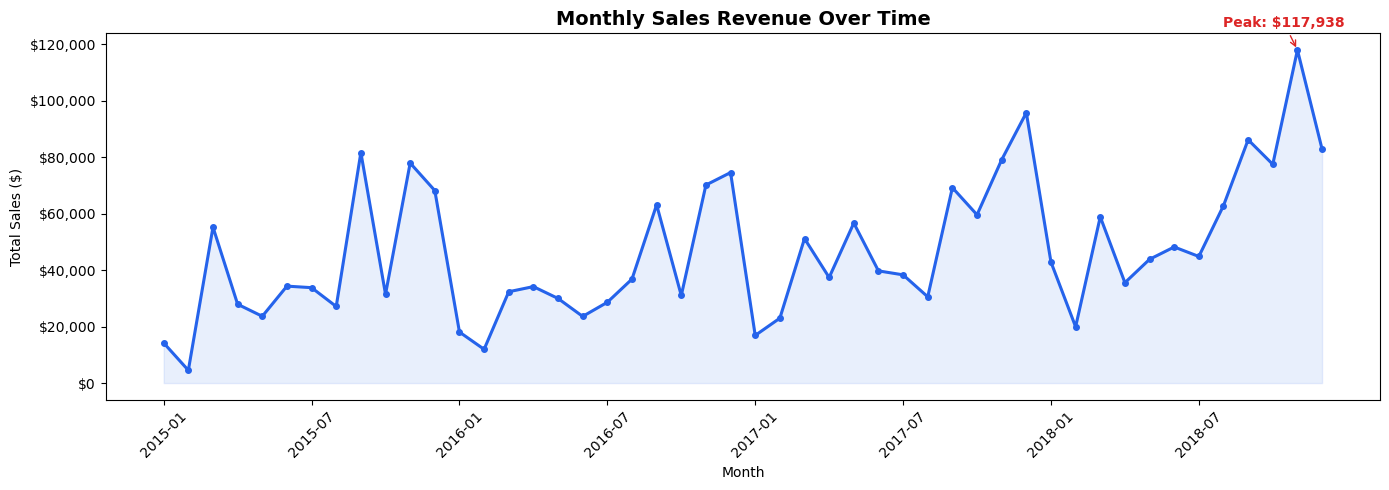

In [69]:
monthly = df.groupby('YearMonth')['Sales'].sum().reset_index()
monthly.columns = ['Month', 'Sales']

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['Month'], monthly['Sales'],
        color='#2563EB', linewidth=2.2, marker='o', markersize=4)
ax.fill_between(monthly['Month'], monthly['Sales'], alpha=0.1, color='#2563EB')

max_idx = monthly['Sales'].idxmax()
ax.annotate(f"Peak: ${monthly['Sales'][max_idx]:,.0f}",
            xy=(monthly['Month'][max_idx], monthly['Sales'][max_idx]),
            xytext=(max_idx - 3, monthly['Sales'][max_idx] + 8000),
            arrowprops=dict(arrowstyle='->', color='#DC2626'),
            color='#DC2626', fontweight='bold')

ax.set_title('Monthly Sales Revenue Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

ticks = list(range(0, len(monthly), 6))
ax.set_xticks([monthly['Month'].iloc[i] for i in ticks])
ax.set_xticklabels([monthly['Month'].iloc[i] for i in ticks], rotation=45)

plt.tight_layout()
plt.savefig('monthly_trend.png', bbox_inches='tight', dpi=150)
plt.show()

##### Insights:
Sales consistently spike in **Q4 (October–December)** across all years, which is typical in US retail driven by holiday purchasing. The business should plan inventory builds and promotional campaigns ahead of October each year. The overall trend also shows **year-over-year growth**, indicating a healthy, expanding customer base.

#### Region by Category heatmap

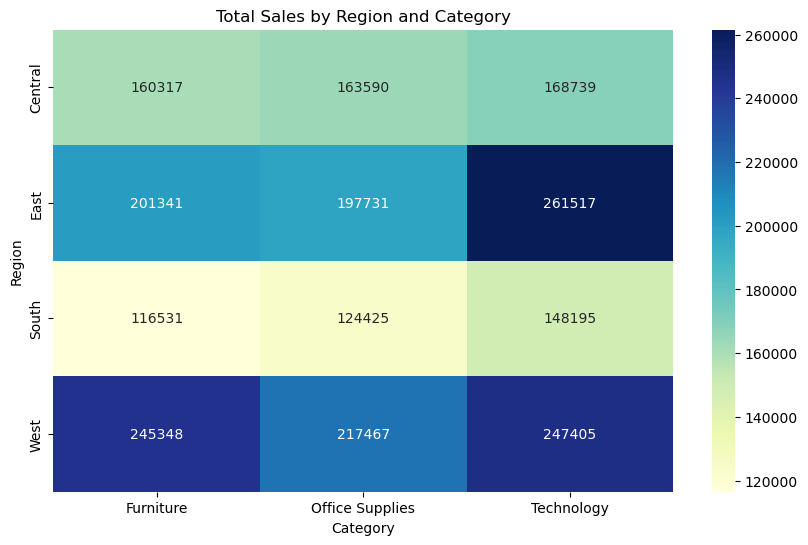

In [70]:
region_category = df.groupby(['Region', 'Category'])['Sales'].sum().unstack()
plt.figure(figsize=(10, 6))
sns.heatmap(region_category, annot=True, fmt=".0f", cmap='YlGnBu')
plt.title('Total Sales by Region and Category')
plt.xlabel('Category')
plt.ylabel('Region')
plt.show()

##### Insights:
The heatmap shows total sales for each combination of Region and Category. Darker colors indicate higher sales. For example, the East region has the highest sales in the Technology category, while the West region has strong sales in Furniture and Office Supplies. This helps identify which categories perform best in each region and be more intentional.

#### Sales by category


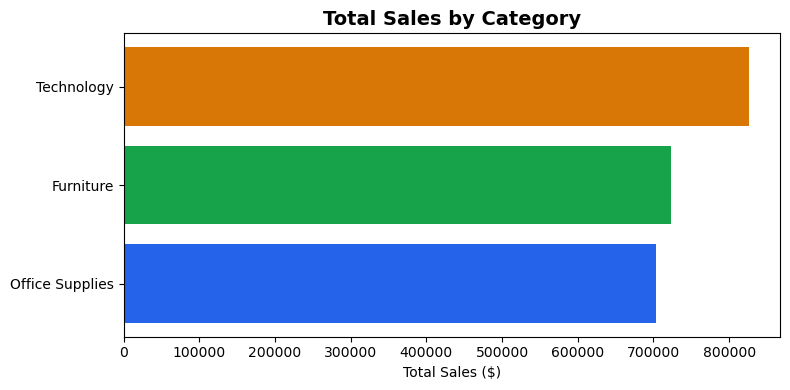

In [71]:
cat_sales = df.groupby('Category')['Sales'].sum().sort_values()

plt.figure(figsize=(8, 4))
plt.barh(cat_sales.index, cat_sales.values,
         color=['#2563EB', '#16A34A', '#D97706'])

plt.title('Total Sales by Category', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('category_sales.png', dpi=150)
plt.show()

##### Insights:
**Technology** generates the most revenue, followed by Furniture. Office Supplies has the most individual orders but lower
average value, meaning customers buy it often but cheaply.

#### Top 10 sub-categories

In [72]:
subcat_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).reset_index()
print(subcat_sales.head(10))

  Sub-Category        Sales
0       Phones  326487.6980
1       Chairs  322107.5310
2      Storage  217779.1020
3       Tables  202810.6280
4      Binders  200028.7850
5     Machines  189238.6310
6  Accessories  163881.6900
7      Copiers  146248.0940
8    Bookcases  109408.2987
9   Appliances  104075.4630


## 5. Machine Learning 
#### Monthly Sales Forecast


In [59]:
pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------- ----------------------------- 2.1/8.1 MB 10.7 MB/s eta 0:00:01
   ---------------------- ----------------- 4.5/8.1 MB 10.8 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.1 MB 11.0 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.1 MB 11.3 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 8.3 MB/s  0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   --- ------------------------------------ 3.1/36.6 MB 16.8 MB/s eta 0:00:02
   ------ --------------------------------- 5.8/36.6 MB 13.6 MB/s eta 0:00:03
   -------- ------------------------------- 8.1/36.6 MB 12.9 MB/s eta 0:00:03
   ------------ --------------------------- 11.0/36.6 MB 13.0 

In [73]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Prepare data
monthly = df.groupby('YearMonth')['Sales'].sum().reset_index()
monthly.columns = ['Month', 'Sales']

X = np.arange(len(monthly)).reshape(-1, 1)
y = monthly['Sales'].values

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

print(f"R² Score: {r2_score(y, y_pred):.4f}")

R² Score: 0.2485


#### Model Performance:

##### R² = 0.2485

The model explains approximately **25% of the variation** in monthly sales. This is expected for a simple time-based Linear Regression model, the remaining 75% of variation is driven by factors not included in the model.

R² Score: 0.2485


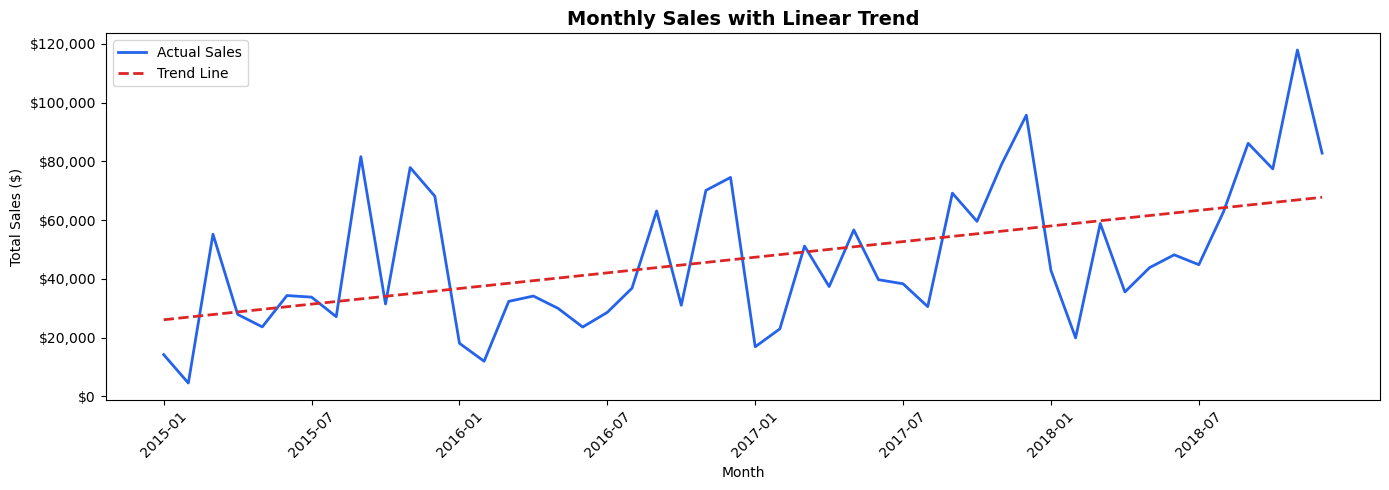

In [ ]:
# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['Month'], y, label='Actual Sales', color='#2563EB', linewidth=2)
ax.plot(monthly['Month'], y_pred, label='Trend Line', color='#DC2626', linestyle='--', linewidth=2)

ax.set_title('Monthly Sales with Linear Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# show every 6th month label so x-axis isn't crowded
ticks = range(0, len(monthly), 6)
ax.set_xticks([monthly['Month'].iloc[i] for i in ticks])
ax.set_xticklabels([monthly['Month'].iloc[i] for i in ticks], rotation=45)

ax.legend()
plt.tight_layout()
plt.savefig('monthly_trend_with_line.png', bbox_inches='tight', dpi=150)
plt.show()

##### The linear regression model above is used to identify the overall trend in monthly sales over time.
**What the model does well:** captures the overall upward revenue trend over time, confirming the business is growing year over year.

**Future Imporvements:** the Q4 seasonal spikes visible in the actual sales line. A more advanced model would handle seasonality and likely achieve a better R^2.